In [32]:
!pip install openpyxl
!pip install wordcloud



In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

In [34]:
# Load the Excel File
file_path = '../.data/lsst_forum_responses.xlsx'
df = pd.read_excel(file_path)

In [35]:
df.head()

,category_id,context,question,question_author,question_date,answer,answer_author,answer_date,primary_group_name,flair_name,flair_url,moderator,admin,staff,is_accepted_answer
0,6,RubinObservatory.org site issue with Chrome on...,"<p>Hello, Rubin website team-</p>\n<p>This is ...",229,2025-02-06,<p>I think you pinpointed the problem—once a p...,TomLoredo,2025-02-07,NaN,NaN,NaN,False,False,False,False
1,6,RubinObservatory.org site issue with Chrome on...,"<p>Hello, Rubin website team-</p>\n<p>This is ...",229,2025-02-06,<p>Yes! It turned out that this was a known is...,MelissaGraham,2025-02-07,LSSTDM,CST,hands-helping,True,True,True,False
2,6,RubinObservatory.org site issue with Chrome on...,"<p>Hello, Rubin website team-</p>\n<p>This is ...",229,2025-02-06,"<p>Hi <a class=""mention"" href=""/u/tomloredo"">@...",MelissaGraham,2025-02-06,LSSTDM,CST,hands-helping,True,True,True,True
3,59,"Rubin Science Assembly, Thu Feb 6 2025: Lookin...","<p><strong>Date:</strong> Thu Feb 6 2025, 9:00...",175,2025-02-04,"<p>Slides:</p>\n<p><a class=""attachment"" href=...",MelissaGraham,2025-02-06,LSSTDM,CST,hands-helping,True,True,True,False
4,60,UK IDAC offline for maintenance during 4th--5t...,<p>Apologies for short notice. Due to planned ...,245,2025-02-04,<p>The UK IDAC is now back online. Apologies f...,george_beckett,2025-02-06,NaN,NaN,NaN,True,False,True,True


In [36]:
print("Shape of the data:", df.shape)

Shape of the data: (8029, 15)


In [37]:
print("Column names:", df.columns.tolist())

Column names: ['category_id', 'context', 'question', 'question_author', 'question_date', 'answer', 'answer_author', 'answer_date', 'primary_group_name', 'flair_name', 'flair_url', 'moderator', 'admin', 'staff', 'is_accepted_answer']


In [38]:
print("\nData Types:\n", df.dtypes)


Data Types:
 category_id                    int64
context                       object
question                      object
question_author                int64
question_date         datetime64[ns]
answer                        object
answer_author                 object
answer_date           datetime64[ns]
primary_group_name            object
flair_name                    object
flair_url                     object
moderator                       bool
admin                           bool
staff                           bool
is_accepted_answer              bool
dtype: object


In [39]:
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 category_id              0
context                  0
question                 5
question_author          0
question_date            0
answer                  53
answer_author            0
answer_date              0
primary_group_name    2951
flair_name            2908
flair_url             7086
moderator                0
admin                    0
staff                    0
is_accepted_answer       0
dtype: int64


In [40]:
print("Summary:\n", df.describe(include='all'))

Summary:
         category_id                                            context  \
count   8029.000000                                               8029   
unique          NaN                                               1628   
top             NaN  Bad termination from running singleFrameDriver...   
freq            NaN                                                 19   
first           NaN                                                NaN   
last            NaN                                                NaN   
mean      18.255449                                                NaN   
std       16.501570                                                NaN   
min        3.000000                                                NaN   
25%        6.000000                                                NaN   
50%       10.000000                                                NaN   
75%       34.000000                                                NaN   
max       61.000000         

/var/folders/6n/w6q7td3d1r72qclcnk1t5skc0000gn/T/ipykernel_39597/1207637627.py:1: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  print("Summary:\n", df.describe(include='all'))
/var/folders/6n/w6q7td3d1r72qclcnk1t5skc0000gn/T/ipykernel_39597/1207637627.py:1: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  print("Summary:\n", df.describe(include='all'))


In [41]:
df['answer_str'] = df['answer'].astype(str)
df['question_str'] = df['question'].astype(str)
df.columns.to_list()

['category_id',
 'context',
 'question',
 'question_author',
 'question_date',
 'answer',
 'answer_author',
 'answer_date',
 'primary_group_name',
 'flair_name',
 'flair_url',
 'moderator',
 'admin',
 'staff',
 'is_accepted_answer',
 'answer_str',
 'question_str']

In [42]:
df['answer_length'] = df['answer_str'].apply(lambda x: len(x.split()))
df['question_length'] = df['question_str'].apply(lambda x: len(x.split()))
df.columns.to_list()

['category_id',
 'context',
 'question',
 'question_author',
 'question_date',
 'answer',
 'answer_author',
 'answer_date',
 'primary_group_name',
 'flair_name',
 'flair_url',
 'moderator',
 'admin',
 'staff',
 'is_accepted_answer',
 'answer_str',
 'question_str',
 'answer_length',
 'question_length']

In [43]:
# Response time
df['response_time_days'] = (df['answer_date'] - df['question_date']).dt.days
print(df['response_time_days'].head())
print(df['response_time_days'].max())
print(df['response_time_days'].min()) # cant be negative ofc ---- getting -36


0    1
1    1
2    0
3    2
4    2
Name: response_time_days, dtype: int64
2138
-36


In [44]:
# Weekdays and hours
df['question_weekday'] = df['question_date'].dt.day_name()
df['answer_weekday'] = df['answer_date'].dt.day_name()
df['question_hour'] = df['question_date'].dt.hour
print(df.columns.to_list())
print(df.head())


['category_id', 'context', 'question', 'question_author', 'question_date', 'answer', 'answer_author', 'answer_date', 'primary_group_name', 'flair_name', 'flair_url', 'moderator', 'admin', 'staff', 'is_accepted_answer', 'answer_str', 'question_str', 'answer_length', 'question_length', 'response_time_days', 'question_weekday', 'answer_weekday', 'question_hour']
   category_id                                            context  \
0            6  RubinObservatory.org site issue with Chrome on...   
1            6  RubinObservatory.org site issue with Chrome on...   
2            6  RubinObservatory.org site issue with Chrome on...   
3           59  Rubin Science Assembly, Thu Feb 6 2025: Lookin...   
4           60  UK IDAC offline for maintenance during 4th--5t...   

                                            question  question_author  \
0  <p>Hello, Rubin website team-</p>\n<p>This is ...              229   
1  <p>Hello, Rubin website team-</p>\n<p>This is ...              229   
2  <

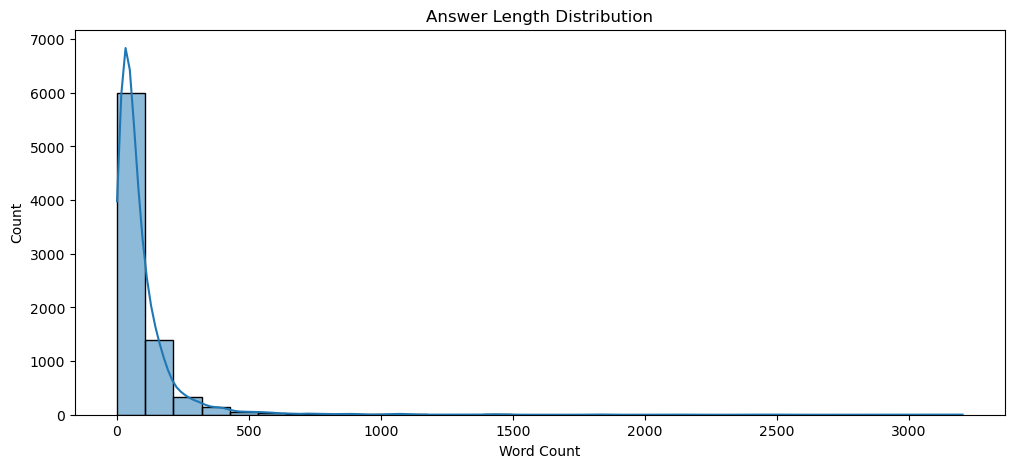

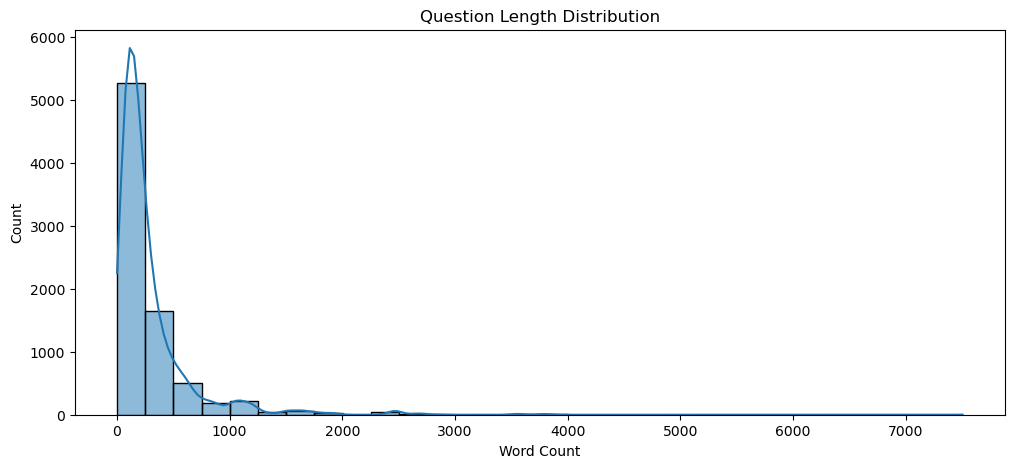

In [45]:
# Text Lengths Viz
plt.figure(figsize=(12, 5))
sns.histplot(df['answer_length'], bins=30, kde=True)
plt.title('Answer Length Distribution')
plt.xlabel('Word Count')
plt.show()

plt.figure(figsize=(12, 5))
sns.histplot(df['question_length'], bins=30, kde=True)
plt.title('Question Length Distribution')
plt.xlabel('Word Count')
plt.show()

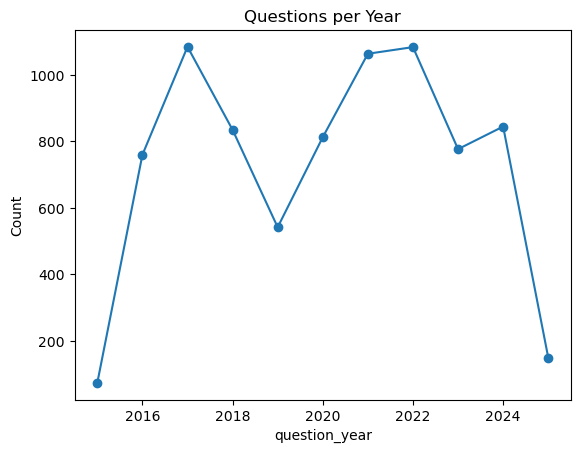

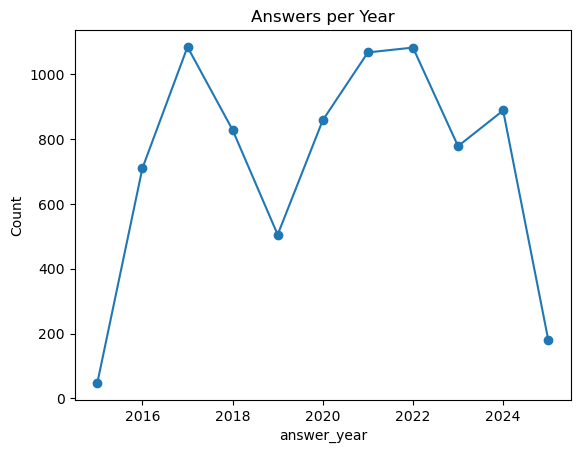

In [46]:
# Yearly Trends
df['question_year'] = df['question_date'].dt.year
df['answer_year'] = df['answer_date'].dt.year

questions_by_year = df.groupby('question_year').size()
answers_by_year = df.groupby('answer_year').size()

questions_by_year.plot(title='Questions per Year', marker='o')
plt.ylabel('Count')
plt.show()

answers_by_year.plot(title='Answers per Year', marker='o')
plt.ylabel('Count')
plt.show()


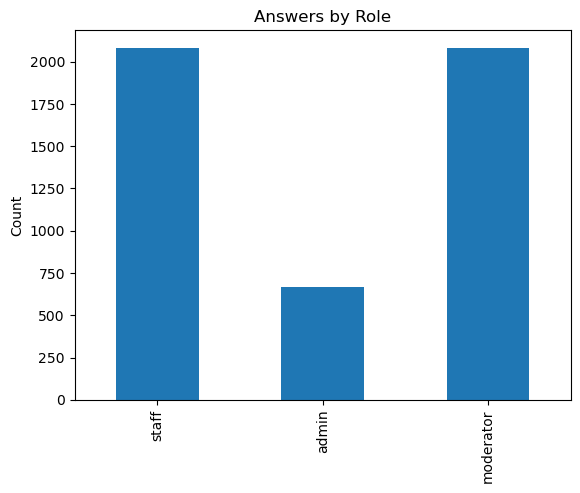

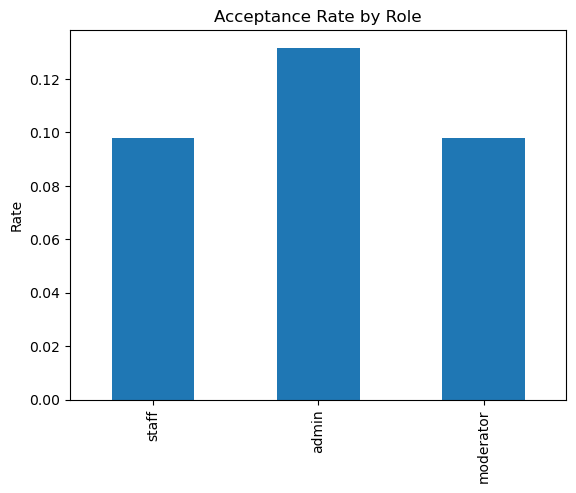

In [58]:
# Role based insights
role_cols = ['staff', 'admin', 'moderator']

answer_counts_by_role = {r: df[df[r]]['answer'].count() for r in role_cols}
acceptance_by_role = {r: df[df[r]]['is_accepted_answer'].mean() for r in role_cols}

pd.Series(answer_counts_by_role).plot(kind='bar', title='Answers by Role')
plt.ylabel('Count')
plt.show()

pd.Series(acceptance_by_role).plot(kind='bar', title='Acceptance Rate by Role')
plt.ylabel('Rate')
plt.show()



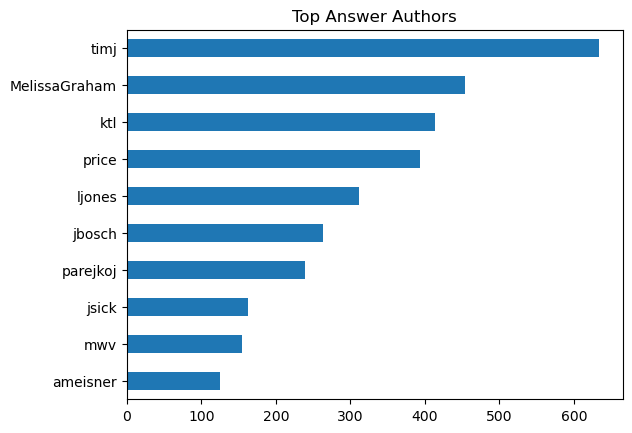

In [48]:
# top contributors
df['question_author_str'] = df['question_author'].astype(str)
df['answer_author_str'] = df['answer_author'].astype(str)

df['answer_author_str'].value_counts().head(10).plot(kind='barh', title='Top Answer Authors')
plt.gca().invert_yaxis()
plt.show()

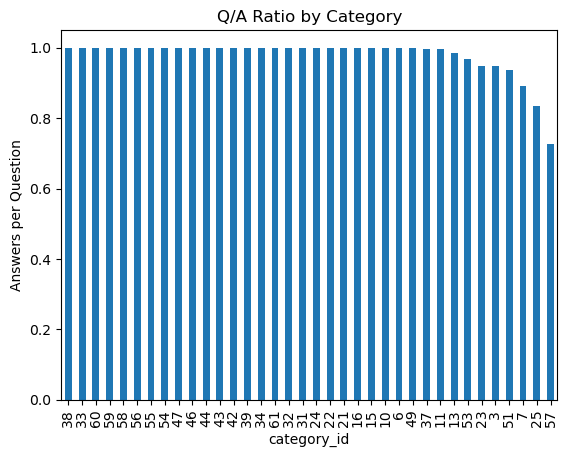

In [60]:
# Q/A Ratio 
qa_ratio = df.groupby('category_id').agg(
    questions=('question', 'count'),
    answers=('answer', lambda x: x.notna().sum())
)
qa_ratio['qa_ratio'] = qa_ratio['answers'] / qa_ratio['questions']
qa_ratio['qa_ratio'].sort_values(ascending=False).plot(kind='bar', title='Q/A Ratio by Category')
plt.ylabel('Answers per Question')
plt.show()



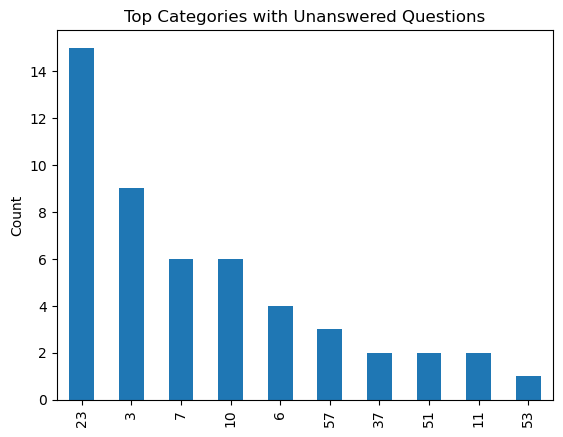

In [50]:
# Unanswered Questions
unanswered = df[df['answer'].isnull()]
unanswered['category_id'].value_counts().head(10).plot(kind='bar', title='Top Categories with Unanswered Questions')
plt.ylabel('Count')
plt.show()



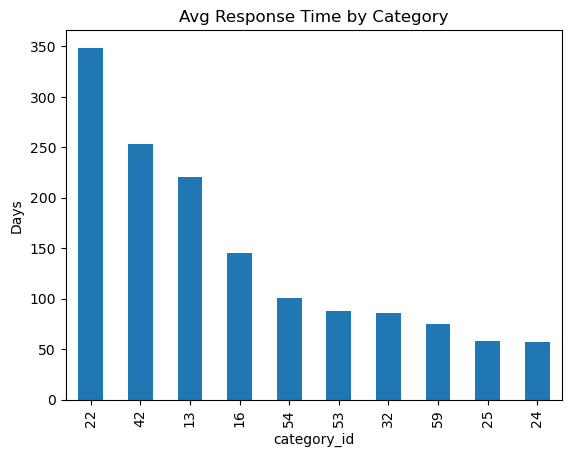

In [51]:
# Response Time by Category
df.groupby('category_id')['response_time_days'].mean().sort_values(ascending=False).head(10).plot(kind='bar', title='Avg Response Time by Category')
plt.ylabel('Days')
plt.show()

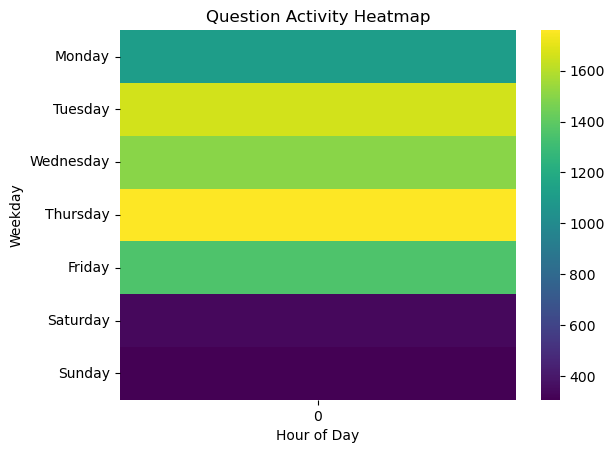

In [52]:
# Heatmap of weekly question activity
heatmap_data = df.groupby(['question_weekday', 'question_hour']).size().unstack(fill_value=0).reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
])
sns.heatmap(heatmap_data, cmap='viridis')
plt.title('Question Activity Heatmap')
plt.xlabel('Hour of Day')
plt.ylabel('Weekday')
plt.show()



In [53]:
# Short, Unaccepted Answers 
short_unaccepted = df[(df['answer_str'].str.split().str.len() < 5) & (~df['is_accepted_answer'])]
print("\nSample of short, unaccepted answers:")
print(short_unaccepted[['answer_author', 'answer_str']].dropna().head(10))



Sample of short, unaccepted answers:
    answer_author                                         answer_str
54      sdhawan21                            <p>Awesome, thanks!</p>
72        ryanlau                                                nan
73       mschwamb                                     <p>Thanks!</p>
78       ameisner                              <p>Thanks, Pedro!</p>
87           timj  <p><code>#gbdesAstrometricFit</code> doesn’t w...
88          VenIl                                        <p>Yes.</p>
106      sdcorle1                                     <p>Thanks.</p>
182      lgirardi                      <p>Yes, I’m there, thanks</p>
192    kklaliotis                           <p>Ah I see. Thanks!</p>
202       Rafaela                     <p>I’m waiting. Thank you.</p>


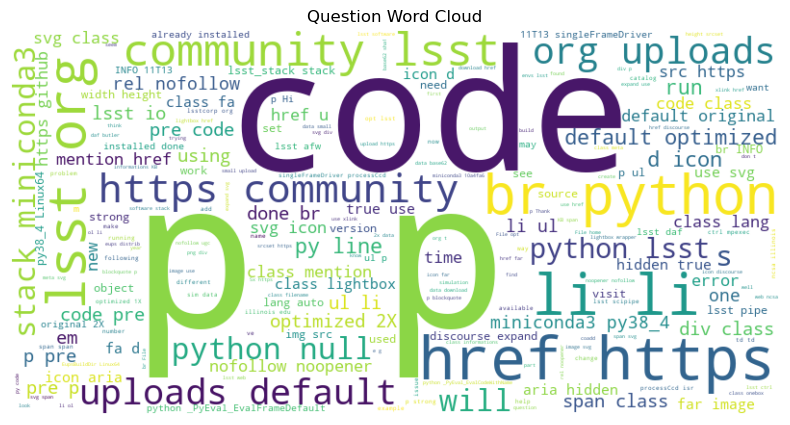

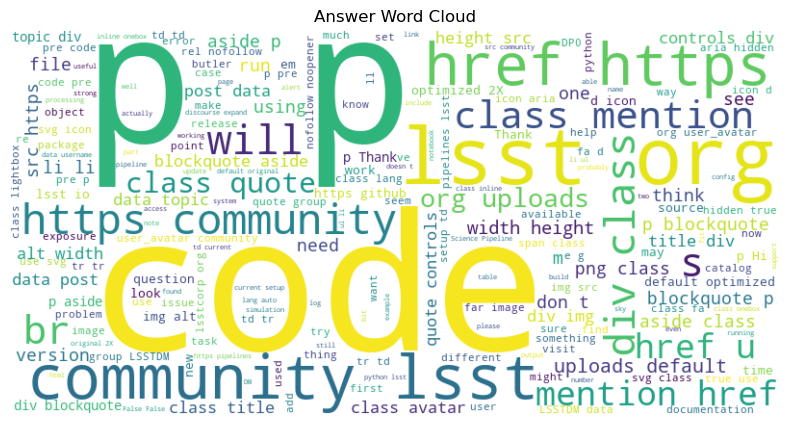

In [54]:
# Word Clouds 
question_sample = " ".join(df['question_str'].dropna().sample(1000, random_state=42))
answer_sample = " ".join(df['answer_str'].dropna().sample(1000, random_state=42))

q_wc = WordCloud(width=800, height=400, background_color='white').generate(question_sample)
a_wc = WordCloud(width=800, height=400, background_color='white').generate(answer_sample)

plt.figure(figsize=(10, 5))
plt.imshow(q_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Question Word Cloud')
plt.show()

plt.figure(figsize=(10, 5))
plt.imshow(a_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Answer Word Cloud')
plt.show()